In [6]:
%matplotlib ipympl
import pandas as pd
import numpy as np
# from scipy.stats import kruskal, mannwhitneyu, ttest_rel, wilcoxon
# import itertools
import statistic_functions as stats
from scipy.io import loadmat
import matplotlib.pyplot as plt
import os 
import z_functions as fncts

from importlib import reload

In [30]:
f1_1_winterStopX = 75
f1_2_bhbf = 79

parent_dir = os.path.abspath('..')

pathData = os.path.join(parent_dir,'cybathlon_results')
savingPath = f'{pathData}/images'

In [ ]:
user2019 = loadmat(f'{pathData}/run_centroids_user_1band.mat')
user2023 = loadmat(f'{pathData}/run_centroids_user_20232024_20192020ref_1band.mat')
# user2023 = loadmat(f'{pathData}/run_centroids_user_20232024_1band.mat')


eyeDistance2019 = user2019['d_ToEye']/ user2019['mAbsDev_centroids']
eyeDistance2023 = user2023['d_ToEye']/ user2023['mAbsDev_centroids']

labels2019 = np.zeros(eyeDistance2019.shape[1])
labels2019[f1_1_winterStopX:] = 1
labels2023 = np.ones(eyeDistance2023.shape[1])*2
labels2023[f1_2_bhbf:] = 3

eyeDistance = np.concatenate((eyeDistance2019, eyeDistance2023), axis=1)
labels = np.concatenate((labels2019, labels2023))

In [ ]:
user1 = pd.read_csv(f"{pathData}/results_user_2019.csv")
user2 = pd.read_csv(f"{pathData}/results_user_2023.csv")

user1['dayId'] = user1.nDay
user2['dayId'] = user2.nDay
user2['nDay'] += user1.nDay.max() + 1
user2['nRun'] += user1.nRun.max() + 1

user = pd.concat([user1, user2], ignore_index=True)       

count = -1
dayOld = -1
for idx, row in user.iterrows():
    if row['dayId'] != dayOld:
        count += 1
        dayOld = row['dayId']
    user.at[idx, 'nDay'] = count

day_start = (
    user
    .drop_duplicates(subset='nDay', keep='first')
    .sort_index()
)

day_start_idx = day_start['nRun'].to_numpy()
day_lbl = day_start['dayLabel'].to_numpy()

day_labels = []
for i, lab in enumerate(day_lbl):
    if i % 2== 0:
        day_labels.append(lab)
    else:
        day_labels.append('')

days_modelCreation = [
    "02/05/2019",
    "09/07/2019",
    "27/10/2020",
    "03/10/2023",
    "11/10/2024",
    "14/10/2024",
    "03/10/2023",
    "02/11/2023",
    "28/11/2023",
    "07/12/2023",
    "19/12/2023",
    "08/07/2024",
    "02/10/2024",
    "04/10/2024",
    "07/10/2024"
]
stop_training = ['10/09/2020', '05/10/2023']  #'11/10/2024',
stop_idx = np.array([next((day_start_idx[i] for i, s in enumerate(day_lbl) if s == pattern), np.nan) for pattern in stop_training])
recalibrations = days_modelCreation[1:]
rec_idx = np.array([next((day_start_idx[i] for i, s in enumerate(day_lbl) if s == pattern), np.nan) for pattern in recalibrations])

In [109]:
label_start_idx ={}
for lbl in labels:
    if lbl not in label_start_idx:
        label_start_idx[lbl] = np.where(labels == lbl)[0][0]

results = fncts.analyze_task_evolution(
    data_array=eyeDistance,
    lbl=labels,
    label_start_idx=label_start_idx,
    bands=None,   # or None for all
    verbose=True
)

Built long-form dataframe with 520 rows
          y  t_aligned label task band
0  0.204200          0   0.0    0    0
1  0.249287          1   0.0    0    0
2  0.292197          2   0.0    0    0
3  0.429864          3   0.0    0    0
4  0.365679          4   0.0    0    0

Using fixed-effect OLS/ANCOVA model (tasks < 5)

ANOVA Table:
                          sum_sq     df           F        PR(>F)
label                  20.911092    3.0   24.481582  8.388152e-15
task                    0.381152    1.0    1.338696  2.478122e-01
label:task              0.678669    3.0    0.794549  4.972965e-01
t_aligned              45.732979    1.0  160.625139  3.796547e-32
t_aligned:label         6.928425    3.0    8.111427  2.765236e-05
t_aligned:task          0.011610    1.0    0.040777  8.400499e-01
t_aligned:label:task    0.071139    3.0    0.083285  9.691330e-01
Residual              143.498219  504.0         NaN           NaN

Estimated per-task slopes (after alignment):
  task     slope
0    0

In [131]:
if eyeDistance.shape[2] > 1:
    eyeDistance = np.mean(eyeDistance, axis=2)
    eyeDistance = eyeDistance[:, :, np.newaxis]


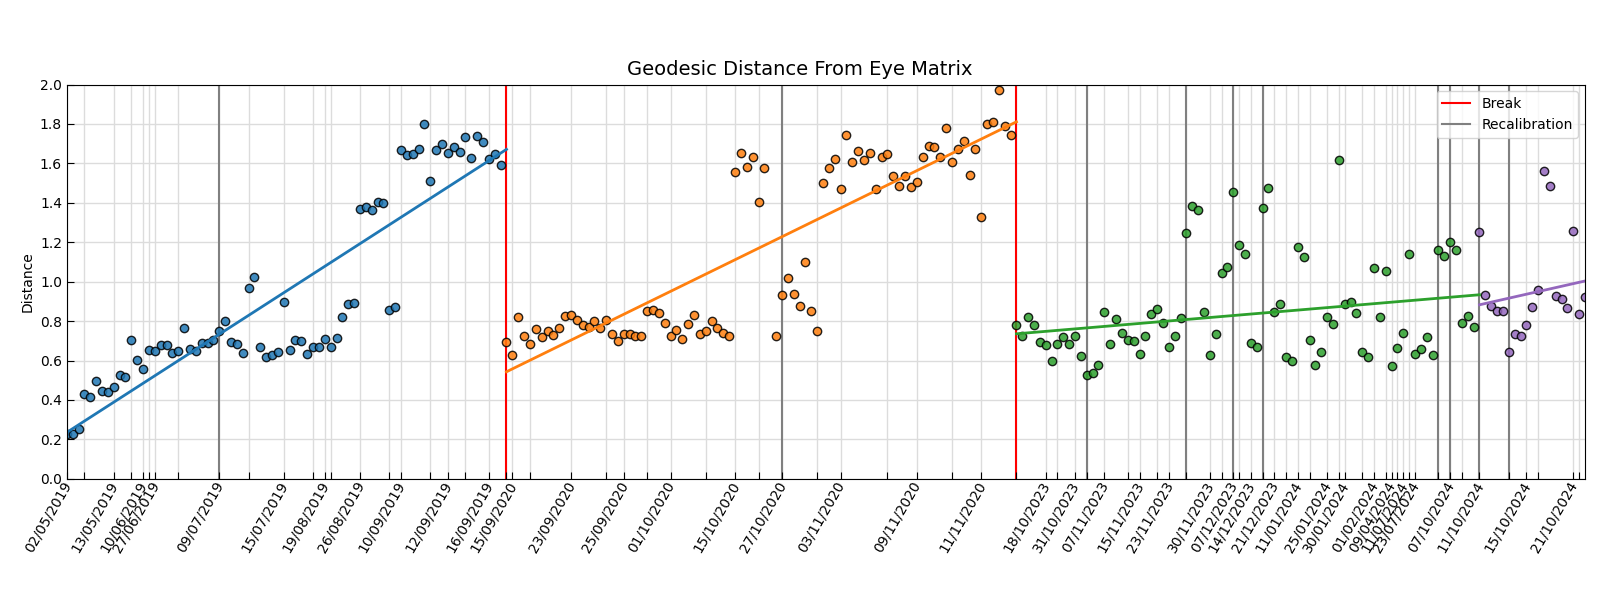

Saving figure to c:\Users\aless\Desktop\cybathlon_results/images/geodesicDistance.svg


In [135]:
reload(fncts)
plt.close('all')
fig = fncts.plot_array_runs_grid(
    eyeDistance,
    lbl=labels,                  # shape: (n_runs,)
    y_col_name="Distance",
    xlim=None, ylim=[0,2],
    fitLine=True,
    scatter=True,
    mergeTask=True,
    averageOnTask=True,
    useHuber=True,
    idxStop=stop_idx,              # int -> red vertical line
    idxRec=rec_idx,               # int -> yellow vertical line
    title='Geodesic Distance From Eye Matrix',
    day_start_idx=day_start_idx,
    day_labels=day_labels,
)

fullpath = f"{savingPath}/geodesicDistance.svg"
print(f"Saving figure to {fullpath}")
fig.savefig(fullpath, bbox_inches='tight', dpi=800, format='svg')

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Build long-form dataframe from your arrays
rows = []
n_bands, n_runs, n_tasks = eyeDistance.shape
data_array = eyeDistance
lbl = labels

for band in range(n_bands):
    for task in range(n_tasks):
        for run in range(n_runs):
            y = data_array[band, run, task]
            if np.isnan(y):
                continue
            lab = lbl[run]
            t0 = label_start_idx[lab]   # dict or array mapping label -> start
            t_aligned = run - t0

            rows.append({
                "y": y,
                "t_aligned": t_aligned,
                "label": str(lab),
                "band": band,
                "task": task
            })

df_long = pd.DataFrame(rows)

# # ANCOVA with interaction
# model = smf.ols(
#     "y ~ t_aligned * label",
#     data=df_long
# ).fit()

# print(model.summary())

import statsmodels.api as sm
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

# “To test whether the observed differences between labels were simply due to differences in start times or reflected genuine label-specific evolution, we aligned each label to its starting time (t_aligned) and performed a linear regression with 
# interaction (y ~ t_aligned * label). The interaction term (t_aligned:label) was highly significant (F(3,252)=11.31, p=5.49e-7), demonstrating that the evolution of each label differs beyond simple temporal shifts. Therefore, the evolution is intrinsic to the labels rather than an artifact of timing.”


                    sum_sq     df           F        PR(>F)
label             6.374136    3.0   12.349563  1.455958e-07
t_aligned        19.225601    1.0  111.745870  7.399954e-22
t_aligned:label   5.839041    3.0   11.312844  5.488236e-07
Residual         43.355978  252.0         NaN           NaN
